# Aurora Finance: Corporate Project Funding Decision
## Step 1: Corporate Finance Module

**Objective:** Identify which internal projects Aurora should fund based on expected economic value and risk-adjusted returns.

**Approach:**
1. Data exploration & feature engineering (NPV, IRR proxies, risk metrics)
2. Regression: predict total project cash flows
3. Classification: predict project success probability
4. Ranking: prioritize projects by expected economic value and risk-adjusted returns
5. SHAP interpretation: explain key drivers to executives

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


C:\Users\Harsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Load & Exploration

In [2]:
# Load data
df = pd.read_csv('data/corporate_projects.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (50, 10)

First 5 rows:
   Project_ID  Department  Investment_Cost  Expected_Cashflow_Year1  \
0           1  Operations           184654                   583556   
1           2   Marketing          2054354                  1447527   
2           3     Finance          2516182                  1372905   
3           4  Operations          3574675                  1817640   
4           5  Operations          2752991                   792139   

   Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
0                  2348816                  1888756            0.08   
1                   541234                   278576            0.15   
2                  1998260                  2312990            0.19   
3                   189182                  1434250            0.22   
4                  1571101                   111087            0.12   

   Market_Growth Project_Risk  Success  
0           0.05          Low        0  
1          -0.01         

In [3]:
# Check success distribution
print("Success Distribution:")
print(df['Success'].value_counts())
print(f"\nSuccess Rate: {df['Success'].mean():.2%}")

# Department breakdown
print("\nProjects by Department:")
print(df['Department'].value_counts())

# Risk distribution
print("\nProjects by Risk Level:")
print(df['Project_Risk'].value_counts())

Success Distribution:
Success
1    26
0    24
Name: count, dtype: int64

Success Rate: 52.00%

Projects by Department:
Department
Marketing     16
Operations    13
IT            11
Finance       10
Name: count, dtype: int64

Projects by Risk Level:
Project_Risk
Medium    20
Low       15
High      15
Name: count, dtype: int64


## 2. Feature Engineering

Create key financial metrics for decision-making.

In [4]:
# Calculate financial metrics
df['Total_Cashflow'] = df['Expected_Cashflow_Year1'] + df['Expected_Cashflow_Year2'] + df['Expected_Cashflow_Year3']

# Net Present Value (simplified: assuming discount rate = 10%)
discount_rate = 0.10
df['NPV'] = (
    df['Expected_Cashflow_Year1'] / (1 + discount_rate)**1 +
    df['Expected_Cashflow_Year2'] / (1 + discount_rate)**2 +
    df['Expected_Cashflow_Year3'] / (1 + discount_rate)**3 -
    df['Investment_Cost']
)

# Profitability Index (Benefit-Cost Ratio)
pv_cashflows = (
    df['Expected_Cashflow_Year1'] / (1 + discount_rate)**1 +
    df['Expected_Cashflow_Year2'] / (1 + discount_rate)**2 +
    df['Expected_Cashflow_Year3'] / (1 + discount_rate)**3
)
df['Profitability_Index'] = pv_cashflows / df['Investment_Cost']

# Risk score (Low=1, Medium=2, High=3)
risk_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['Risk_Score'] = df['Project_Risk'].map(risk_mapping)
# Handle any NaN values from unmapped risk levels
df['Risk_Score'] = df['Risk_Score'].fillna(2)

# Average annual cashflow
df['Avg_Annual_Cashflow'] = df['Total_Cashflow'] / 3

# ROI by project (actual vs historical)
df['Project_ROI'] = (df['Total_Cashflow'] - df['Investment_Cost']) / df['Investment_Cost']

# Efficiency: NPV per investment dollar
df['NPV_per_Dollar'] = df['NPV'] / df['Investment_Cost']

print("Feature Engineering Complete!")
print("\nNew Metrics:")
print(df[['Total_Cashflow', 'NPV', 'Profitability_Index', 'Project_ROI', 'NPV_per_Dollar']].describe())

Feature Engineering Complete!

New Metrics:
       Total_Cashflow           NPV  Profitability_Index  Project_ROI  \
count    5.000000e+01  5.000000e+01            50.000000    50.000000   
mean     3.779571e+06  5.853472e+05             3.229034     2.965607   
std      1.319127e+06  1.844210e+06             6.388352     7.848302   
min      3.867110e+05 -3.809639e+06             0.110209    -0.866445   
25%      2.708749e+06 -6.790079e+05             0.788351    -0.052067   
50%      3.911796e+06  3.196457e+05             1.145099     0.378967   
75%      4.905114e+06  2.025437e+06             1.921029     1.370095   
max      6.181820e+06  4.281887e+06            35.742320    42.735750   

       NPV_per_Dollar  
count       50.000000  
mean         2.229034  
std          6.388352  
min         -0.889791  
25%         -0.211649  
50%          0.145099  
75%          0.921029  
max         34.742320  


## 3. Data Visualization

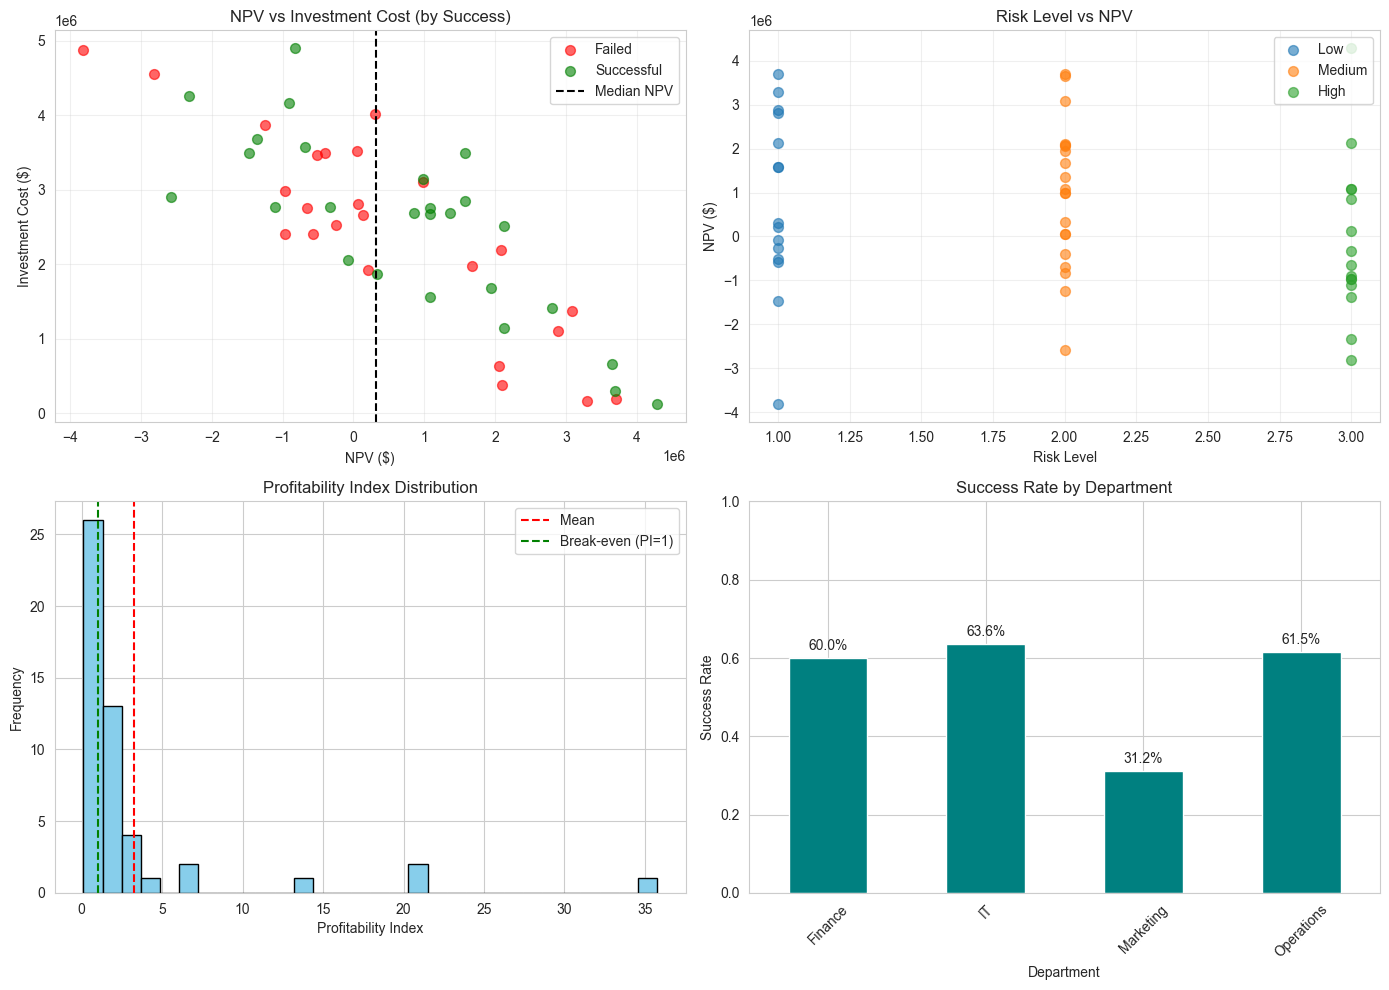

Visualization Complete!


In [5]:
# NPV Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# NPV by Success
axes[0, 0].scatter(df[df['Success']==0]['NPV'], df[df['Success']==0]['Investment_Cost'], 
                    alpha=0.6, label='Failed', color='red', s=50)
axes[0, 0].scatter(df[df['Success']==1]['NPV'], df[df['Success']==1]['Investment_Cost'], 
                    alpha=0.6, label='Successful', color='green', s=50)
axes[0, 0].axvline(df['NPV'].median(), color='black', linestyle='--', label='Median NPV')
axes[0, 0].set_xlabel('NPV ($)')
axes[0, 0].set_ylabel('Investment Cost ($)')
axes[0, 0].set_title('NPV vs Investment Cost (by Success)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Risk vs NPV
for risk in ['Low', 'Medium', 'High']:
    mask = df['Project_Risk'] == risk
    axes[0, 1].scatter(df[mask]['Risk_Score'], df[mask]['NPV'], label=risk, alpha=0.6, s=50)
axes[0, 1].set_xlabel('Risk Level')
axes[0, 1].set_ylabel('NPV ($)')
axes[0, 1].set_title('Risk Level vs NPV')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Profitability Index Distribution
axes[1, 0].hist(df['Profitability_Index'], bins=30, color='skyblue', edgecolor='black')
axes[1, 0].axvline(df['Profitability_Index'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 0].axvline(1.0, color='green', linestyle='--', label='Break-even (PI=1)')
axes[1, 0].set_xlabel('Profitability Index')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Profitability Index Distribution')
axes[1, 0].legend()

# Success Rate by Department
dept_success = df.groupby('Department')['Success'].agg(['sum', 'count'])
dept_success['rate'] = dept_success['sum'] / dept_success['count']
dept_success['rate'].plot(kind='bar', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Success Rate by Department')
axes[1, 1].set_ylabel('Success Rate')
axes[1, 1].set_xlabel('Department')
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(dept_success['rate']):
    axes[1, 1].text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Visualization Complete!")

## 4. Regression Model: Predict Total Cashflow

In [6]:
# Prepare features for regression
features_for_modeling = ['Investment_Cost', 'Historical_ROI', 'Market_Growth', 'Risk_Score']
target_regression = 'Total_Cashflow'

X_reg = df[features_for_modeling].copy()
y_reg = df[target_regression].copy()

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_reg_train = rf_reg.predict(X_train_reg)
y_pred_reg_test = rf_reg.predict(X_test_reg)

# Evaluation
train_r2 = r2_score(y_train_reg, y_pred_reg_train)
test_r2 = r2_score(y_test_reg, y_pred_reg_test)
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_test))

print("Regression Model Performance (Predicting Total Cashflow):")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test RMSE: ${test_rmse:,.0f}")

Regression Model Performance (Predicting Total Cashflow):
Train R²: 0.8255
Test R²: 0.0573
Test RMSE: $1,544,547


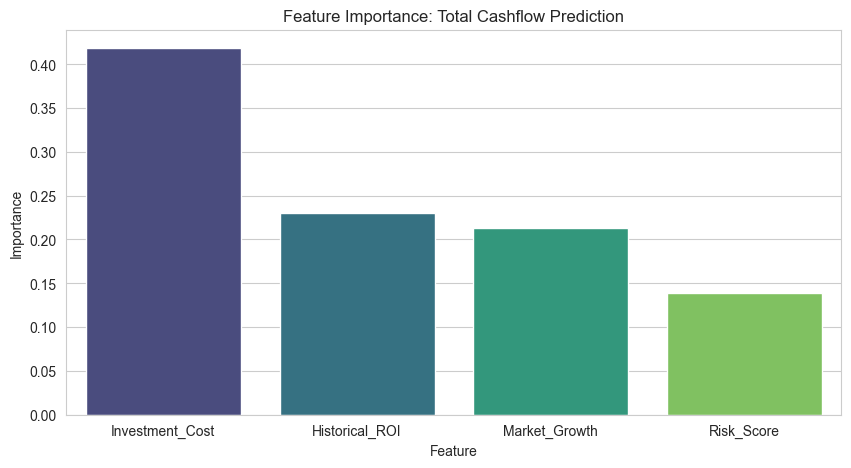


Feature Importance (Regression):
           Feature  Importance
0  Investment_Cost    0.418584
1   Historical_ROI    0.230160
2    Market_Growth    0.212548
3       Risk_Score    0.138707


In [7]:
# Feature importance for regression
feature_imp_reg = pd.DataFrame({
    'Feature': features_for_modeling,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_imp_reg, x='Feature', y='Importance', palette='viridis')
plt.title('Feature Importance: Total Cashflow Prediction')
plt.ylabel('Importance')
plt.show()

print("\nFeature Importance (Regression):")
print(feature_imp_reg)

## 5. Classification Model: Predict Project Success

In [8]:
# Prepare features for classification
features_for_classification = ['Investment_Cost', 'Historical_ROI', 'Market_Growth', 'Risk_Score']
target_classification = 'Success'

X_clf = df[features_for_classification].copy()
y_clf = df[target_classification].copy()

# Train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_clf, y_train_clf)

# Predictions
y_pred_clf_train = rf_clf.predict(X_train_clf)
y_pred_clf_test = rf_clf.predict(X_test_clf)
y_pred_proba_test = rf_clf.predict_proba(X_test_clf)[:, 1]

# Evaluation
train_acc = rf_clf.score(X_train_clf, y_train_clf)
test_acc = rf_clf.score(X_test_clf, y_test_clf)
test_auc = roc_auc_score(y_test_clf, y_pred_proba_test)

print("Classification Model Performance (Predicting Success):")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC-ROC: {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_test, target_names=['Failed', 'Successful']))

Classification Model Performance (Predicting Success):
Train Accuracy: 1.0000
Test Accuracy: 0.4000
Test AUC-ROC: 0.4400

Classification Report:
              precision    recall  f1-score   support

      Failed       0.40      0.40      0.40         5
  Successful       0.40      0.40      0.40         5

    accuracy                           0.40        10
   macro avg       0.40      0.40      0.40        10
weighted avg       0.40      0.40      0.40        10



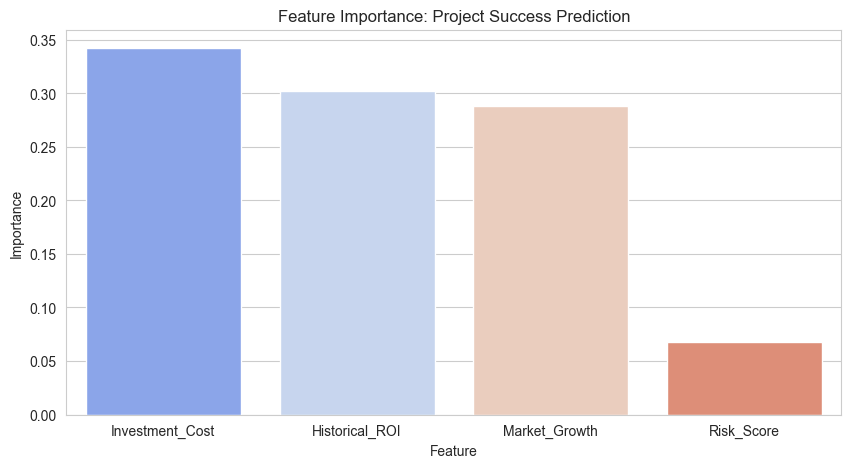


Feature Importance (Classification):
           Feature  Importance
0  Investment_Cost    0.342331
1   Historical_ROI    0.301922
2    Market_Growth    0.288320
3       Risk_Score    0.067428


In [9]:
# Feature importance for classification
feature_imp_clf = pd.DataFrame({
    'Feature': features_for_classification,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_imp_clf, x='Feature', y='Importance', palette='coolwarm')
plt.title('Feature Importance: Project Success Prediction')
plt.ylabel('Importance')
plt.show()

print("\nFeature Importance (Classification):")
print(feature_imp_clf)

## 6. Predict Success Probability for All Projects

In [10]:
# Generate success probability for all projects
df['Predicted_Success_Probability'] = rf_clf.predict_proba(X_clf)[:, 1]

# Also add predicted cashflows
df['Predicted_Cashflow'] = rf_reg.predict(X_reg)

print("Success Probabilities Added!")
print(df[['Project_ID', 'Success', 'Predicted_Success_Probability']].head(10))

Success Probabilities Added!
   Project_ID  Success  Predicted_Success_Probability
0           1        0                       0.140000
1           2        1                       0.810000
2           3        1                       0.770000
3           4        1                       0.790000
4           5        0                       0.160000
5           6        0                       0.110000
6           7        0                       0.200000
7           8        1                       0.960000
8           9        1                       0.663333
9          10        1                       0.700000


## 7. Risk-Adjusted Valuation & Ranking

Rank projects by Expected Economic Value (EV) and risk-adjusted returns.

In [11]:
# Calculate Expected Economic Value (EV)
# EV = Success_Probability * NPV (only count positive NPV if successful)
df['Expected_NPV'] = df['Predicted_Success_Probability'] * df['NPV']

# Risk-adjusted return: (Expected_NPV) / Investment_Cost
df['Risk_Adjusted_Return'] = df['Expected_NPV'] / df['Investment_Cost']

# Composite score: weighted combination of expected NPV and profitability index
# Normalized scores
df['Normalized_Expected_NPV'] = (df['Expected_NPV'] - df['Expected_NPV'].min()) / (df['Expected_NPV'].max() - df['Expected_NPV'].min())
df['Normalized_PI'] = (df['Profitability_Index'] - df['Profitability_Index'].min()) / (df['Profitability_Index'].max() - df['Profitability_Index'].min())

# Composite Score (60% Expected NPV, 40% Profitability Index)
df['Composite_Score'] = 0.6 * df['Normalized_Expected_NPV'] + 0.4 * df['Normalized_PI']

print("Risk-Adjusted Metrics Calculated!")
print(df[['Project_ID', 'Expected_NPV', 'Risk_Adjusted_Return', 'Composite_Score']].head(10))

Risk-Adjusted Metrics Calculated!
   Project_ID  Expected_NPV  Risk_Adjusted_Return  Composite_Score
0           1  5.188501e+05              2.809850         0.565403
1           2 -6.627522e+04             -0.032261         0.273966
2           3  1.633287e+06              0.649113         0.474663
3           4 -5.437989e+05             -0.152125         0.218646
4           5 -1.041556e+05             -0.037834         0.267506
5           6 -2.774668e+04             -0.010974         0.277618
6           7  4.109210e+05              0.654147         0.364698
7           8 -3.144831e+05             -0.113818         0.245219
8           9  9.025945e+05              0.335956         0.388860
9          10  7.539407e+05              0.282332         0.371015


## 8. Project Ranking & Recommendations

In [12]:
# Rank by Composite Score
ranking_df = df[[
    'Project_ID', 'Department', 'Investment_Cost', 'NPV', 'Expected_NPV',
    'Profitability_Index', 'Predicted_Success_Probability', 'Project_Risk',
    'Historical_ROI', 'Market_Growth', 'Composite_Score', 'Success'
]].copy()

ranking_df['Rank'] = ranking_df['Composite_Score'].rank(ascending=False, method='min')
ranking_df = ranking_df.sort_values('Rank')

print("\n" + "="*120)
print("TOP 15 PROJECTS FOR FUNDING")
print("="*120)
print(ranking_df.head(15).to_string(index=False))

print("\n" + "="*120)
print("BOTTOM 10 PROJECTS (NOT RECOMMENDED)")
print("="*120)
print(ranking_df.tail(10).to_string(index=False))


TOP 15 PROJECTS FOR FUNDING
 Project_ID Department  Investment_Cost          NPV  Expected_NPV  Profitability_Index  Predicted_Success_Probability Project_Risk  Historical_ROI  Market_Growth  Composite_Score  Success  Rank
         49         IT           123247 4.281887e+06  7.707396e+05            35.742320                           0.18         High            0.09           0.01         0.758385        1   1.0
         35         IT           296769 3.690876e+06  2.805066e+06            13.436865                           0.76       Medium            0.23          -0.03         0.736353        1   2.0
         43         IT           664685 3.653868e+06  2.923094e+06             6.497142                           0.80       Medium            0.24           0.14         0.671699        1   3.0
          1 Operations           184654 3.706072e+06  5.188501e+05            21.070359                           0.14          Low            0.08           0.05         0.565403        0   

In [13]:
# Summary statistics by recommendation
# Top 20% for funding
threshold = ranking_df['Composite_Score'].quantile(0.80)
df['Recommendation'] = df['Composite_Score'].apply(
    lambda x: 'FUND' if x >= threshold else ('MONITOR' if x >= ranking_df['Composite_Score'].quantile(0.50) else 'REJECT')
)

# Add Recommendation to ranking_df for dashboard
ranking_df['Recommendation'] = df['Recommendation'].values

print("\nRecommendation Distribution:")
print(df['Recommendation'].value_counts())

print("\nAverage Metrics by Recommendation:")
summary = df.groupby('Recommendation')[[
    'Investment_Cost', 'NPV', 'Expected_NPV', 'Profitability_Index',
    'Predicted_Success_Probability', 'Success'
]].mean()
print(summary)


Recommendation Distribution:
Recommendation
REJECT     25
MONITOR    15
FUND       10
Name: count, dtype: int64

Average Metrics by Recommendation:
                Investment_Cost           NPV  Expected_NPV  \
Recommendation                                                
FUND                  1036941.1  2.935055e+06  1.502241e+06   
MONITOR               2152962.4  1.535386e+06  7.582752e+05   
REJECT                3311069.8 -9.245593e+05 -4.543616e+05   

                Profitability_Index  Predicted_Success_Probability  Success  
Recommendation                                                               
FUND                      11.309794                       0.555000      0.7  
MONITOR                    1.982409                       0.585111      0.6  
REJECT                     0.744704                       0.464467      0.4  


## 9. SHAP Explainability

<Figure size 1000x600 with 0 Axes>

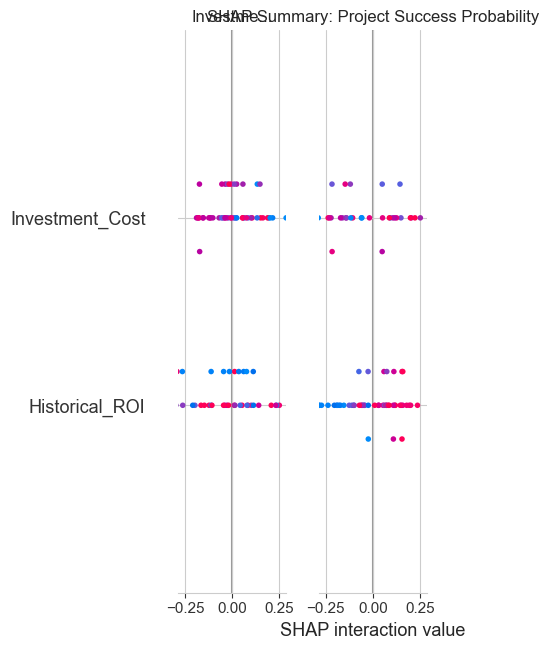

SHAP Classification Summary Plot Generated!


In [14]:
# SHAP for Classification Model (Success Prediction)
explainer_clf = shap.TreeExplainer(rf_clf)
shap_values_clf = explainer_clf.shap_values(X_clf)

# Summary bar plot with feature importance
plt.figure(figsize=(10, 6))
try:
    # Try standard summary plot
    if isinstance(shap_values_clf, list) and len(shap_values_clf) > 1:
        shap.summary_plot(shap_values_clf[1], X_clf, feature_names=features_for_classification, 
                         show=False, plot_type='bar')
    else:
        shap.summary_plot(shap_values_clf, X_clf, feature_names=features_for_classification, 
                         show=False, plot_type='bar')
except:
    # Fallback: plot feature importance
    feat_imp = pd.DataFrame({
        'Feature': features_for_classification,
        'Importance': rf_clf.feature_importances_
    }).sort_values('Importance', ascending=True)
    plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
    
plt.title('SHAP Summary: Project Success Probability')
plt.tight_layout()
plt.show()

print("SHAP Classification Summary Plot Generated!")

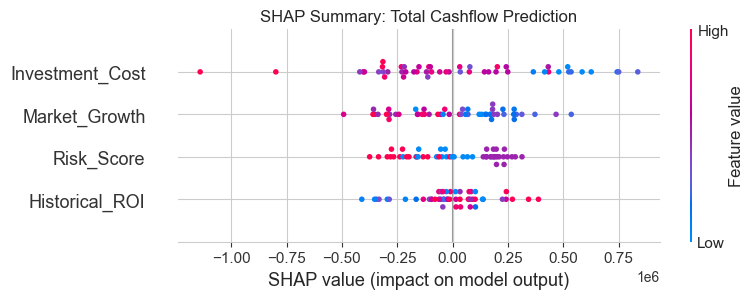

SHAP Regression Summary Plot Generated!


In [15]:
# SHAP for Regression Model (Cashflow Prediction)
explainer_reg = shap.TreeExplainer(rf_reg)
shap_values_reg = explainer_reg.shap_values(X_reg)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_reg, X_reg, feature_names=features_for_modeling, show=False)
plt.title('SHAP Summary: Total Cashflow Prediction')
plt.tight_layout()
plt.show()

print("SHAP Regression Summary Plot Generated!")

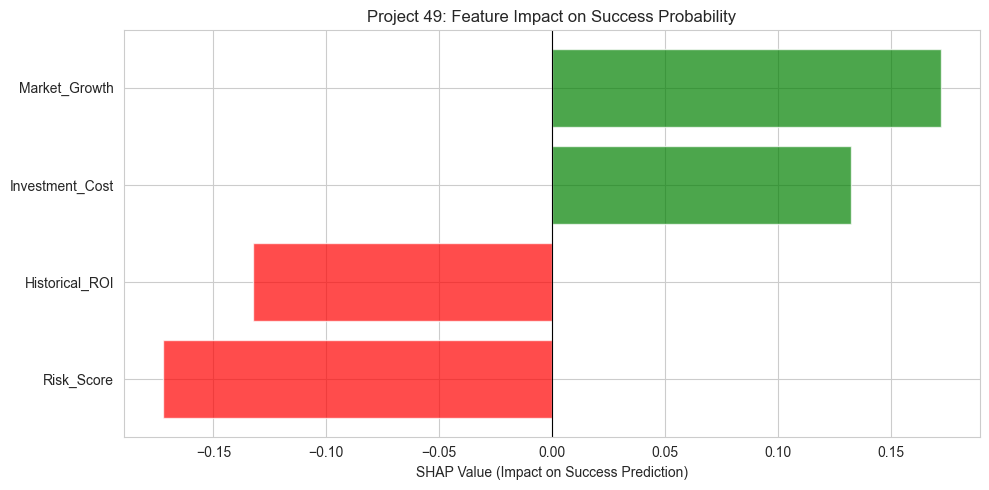

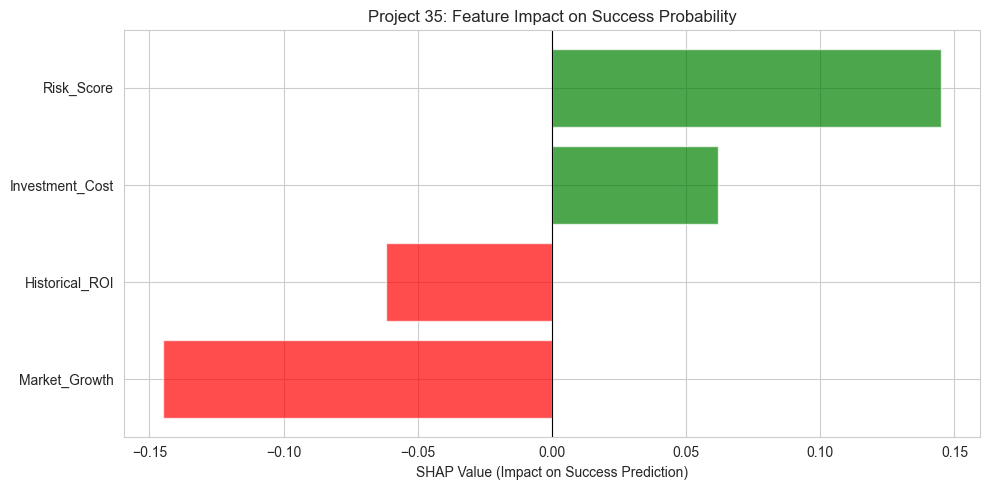

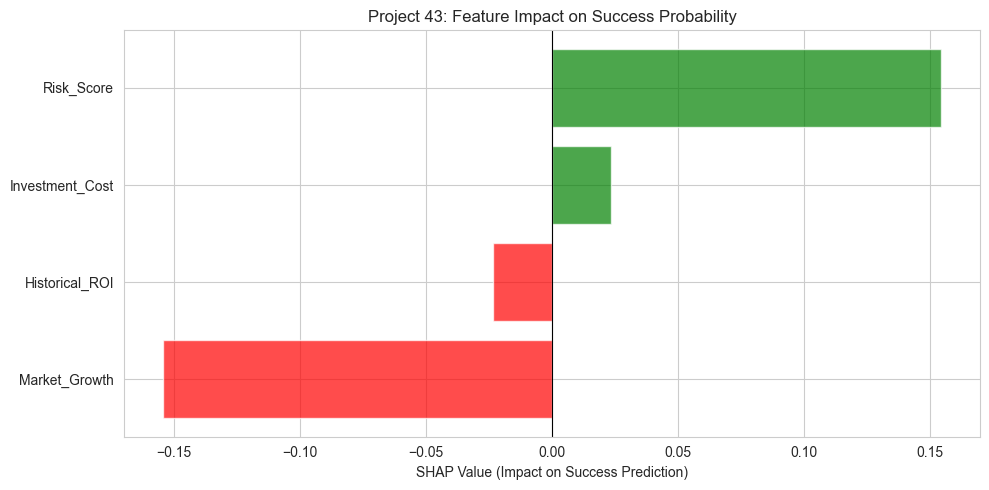

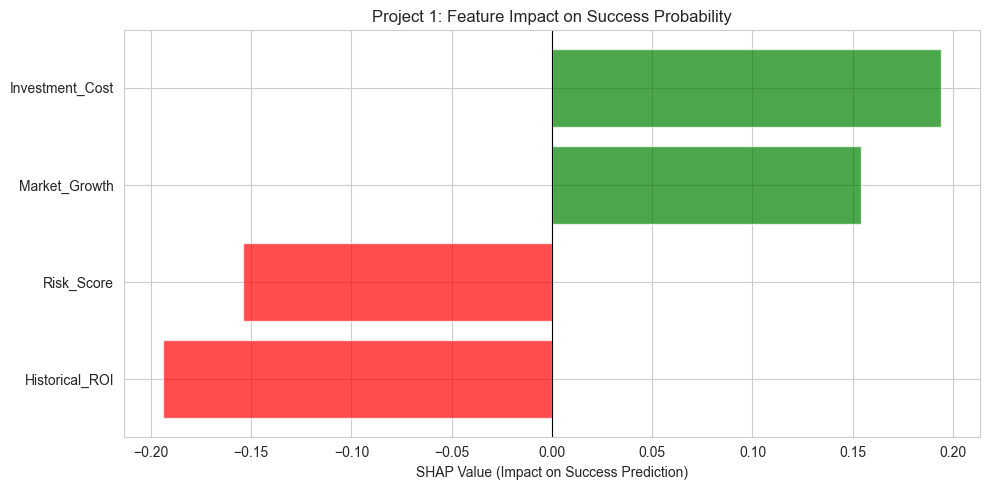

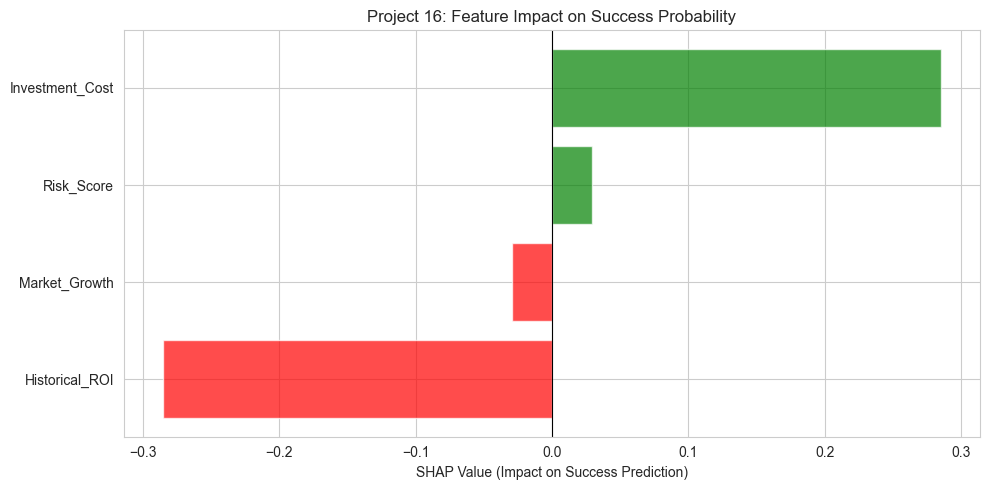

In [23]:
# Individual SHAP explanation for top recommended projects (simplified)
top_projects_list = ranking_df.head(5)['Project_ID'].tolist()

for proj_id in top_projects_list:
    # Find correct index in original df
    idx = df[df['Project_ID'] == proj_id].index[0]
    
    # Get SHAP values for this instance - flatten if needed
    if isinstance(shap_values_clf, list) and len(shap_values_clf) > 1:
        shap_vals = shap_values_clf[1][idx]
    else:
        shap_vals = shap_values_clf[idx]
    
    # Ensure 1D array
    shap_vals = np.asarray(shap_vals).flatten()
    
    # Simple bar plot of SHAP contributions
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Create sorted list for plotting
    feat_shap_pairs = list(zip(features_for_classification, shap_vals))
    feat_shap_pairs.sort(key=lambda x: x[1])
    
    feats = [f[0] for f in feat_shap_pairs]
    vals = [f[1] for f in feat_shap_pairs]
    colors = ['red' if v < 0 else 'green' for v in vals]
    
    ax.barh(feats, vals, color=colors, alpha=0.7)
    ax.set_xlabel('SHAP Value (Impact on Success Prediction)')
    ax.set_title(f'Project {proj_id}: Feature Impact on Success Probability')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.tight_layout()
    plt.show()

## 10. Executive Summary & Recommendations

In [17]:
print("\n" + "="*100)
print("EXECUTIVE SUMMARY: CORPORATE PROJECT FUNDING RECOMMENDATIONS")
print("="*100)

print(f"\n📊 PORTFOLIO OVERVIEW:")
print(f"  • Total Projects Analyzed: {len(df)}")
print(f"  • Total Investment Required (Top 20): ${ranking_df.head(20)['Investment_Cost'].sum():,.0f}")
print(f"  • Expected NPV (Top 20): ${ranking_df.head(20)['Expected_NPV'].sum():,.0f}")
print(f"  • Average Success Probability (Top 20): {ranking_df.head(20)['Predicted_Success_Probability'].mean():.1%}")

print(f"\n🎯 RECOMMENDATION SUMMARY:")
fund_count = len(df[df['Recommendation'] == 'FUND'])
monitor_count = len(df[df['Recommendation'] == 'MONITOR'])
reject_count = len(df[df['Recommendation'] == 'REJECT'])
print(f"  • FUND (Top 20%): {fund_count} projects")
print(f"  • MONITOR (Middle 30%): {monitor_count} projects")
print(f"  • REJECT (Bottom 50%): {reject_count} projects")

print(f"\n💰 FINANCIAL IMPACT:")
fund_projects = df[df['Recommendation'] == 'FUND']
print(f"  • Total Investment (FUND): ${fund_projects['Investment_Cost'].sum():,.0f}")
print(f"  • Expected NPV (FUND): ${fund_projects['Expected_NPV'].sum():,.0f}")
print(f"  • Avg ROI (FUND): {fund_projects['Project_ROI'].mean():.1%}")
print(f"  • Avg Success Rate: {fund_projects['Predicted_Success_Probability'].mean():.1%}")

print(f"\n🏢 TOP RECOMMENDATIONS BY DEPARTMENT:")
for dept in df['Department'].unique():
    dept_fund = df[(df['Department'] == dept) & (df['Recommendation'] == 'FUND')]
    if len(dept_fund) > 0:
        print(f"  • {dept}: {len(dept_fund)} projects, Total NPV: ${dept_fund['Expected_NPV'].sum():,.0f}")

print(f"\n⚠️  KEY INSIGHTS:")
print(f"  1. Risk vs Return: Higher-risk projects have {df[df['Project_Risk']=='High']['Predicted_Success_Probability'].mean():.1%} success rate vs {df[df['Project_Risk']=='Low']['Predicted_Success_Probability'].mean():.1%} for low-risk")
print(f"  2. Investment Size: Larger investments don't guarantee better returns (correlation: {df['Investment_Cost'].corr(df['Expected_NPV']):.2f})")
print(f"  3. Market Conditions: Projects in growing markets have {df[df['Market_Growth']>0]['Predicted_Success_Probability'].mean():.1%} success rate")

print(f"\n✅ ACTION ITEMS:")
print(f"  1. Immediate: Fund top 10 projects (Rank 1-10) - Expected combined NPV: ${ranking_df.head(10)['Expected_NPV'].sum():,.0f}")
print(f"  2. Secondary: Review monitoring projects with improving market conditions")
print(f"  3. Risk Management: Diversify by department and risk level")
print(f"  4. Timeline: Prioritize projects with high profitability index for faster payback")

print("\n" + "="*100)


EXECUTIVE SUMMARY: CORPORATE PROJECT FUNDING RECOMMENDATIONS

📊 PORTFOLIO OVERVIEW:
  • Total Projects Analyzed: 50
  • Total Investment Required (Top 20): $32,177,960
  • Expected NPV (Top 20): $24,046,933
  • Average Success Probability (Top 20): 58.8%

🎯 RECOMMENDATION SUMMARY:
  • FUND (Top 20%): 10 projects
  • MONITOR (Middle 30%): 15 projects
  • REJECT (Bottom 50%): 25 projects

💰 FINANCIAL IMPACT:
  • Total Investment (FUND): $10,369,411
  • Expected NPV (FUND): $15,022,414
  • Avg ROI (FUND): 1292.1%
  • Avg Success Rate: 55.5%

🏢 TOP RECOMMENDATIONS BY DEPARTMENT:
  • Operations: 2 projects, Total NPV: $1,900,186
  • Marketing: 1 projects, Total NPV: $2,077,028
  • Finance: 4 projects, Total NPV: $4,546,300
  • IT: 3 projects, Total NPV: $6,498,900

⚠️  KEY INSIGHTS:
  1. Risk vs Return: Higher-risk projects have 53.9% success rate vs 42.4% for low-risk
  2. Investment Size: Larger investments don't guarantee better returns (correlation: -0.59)
  3. Market Conditions: Proje

## 11. Visualization: Portfolio Dashboard

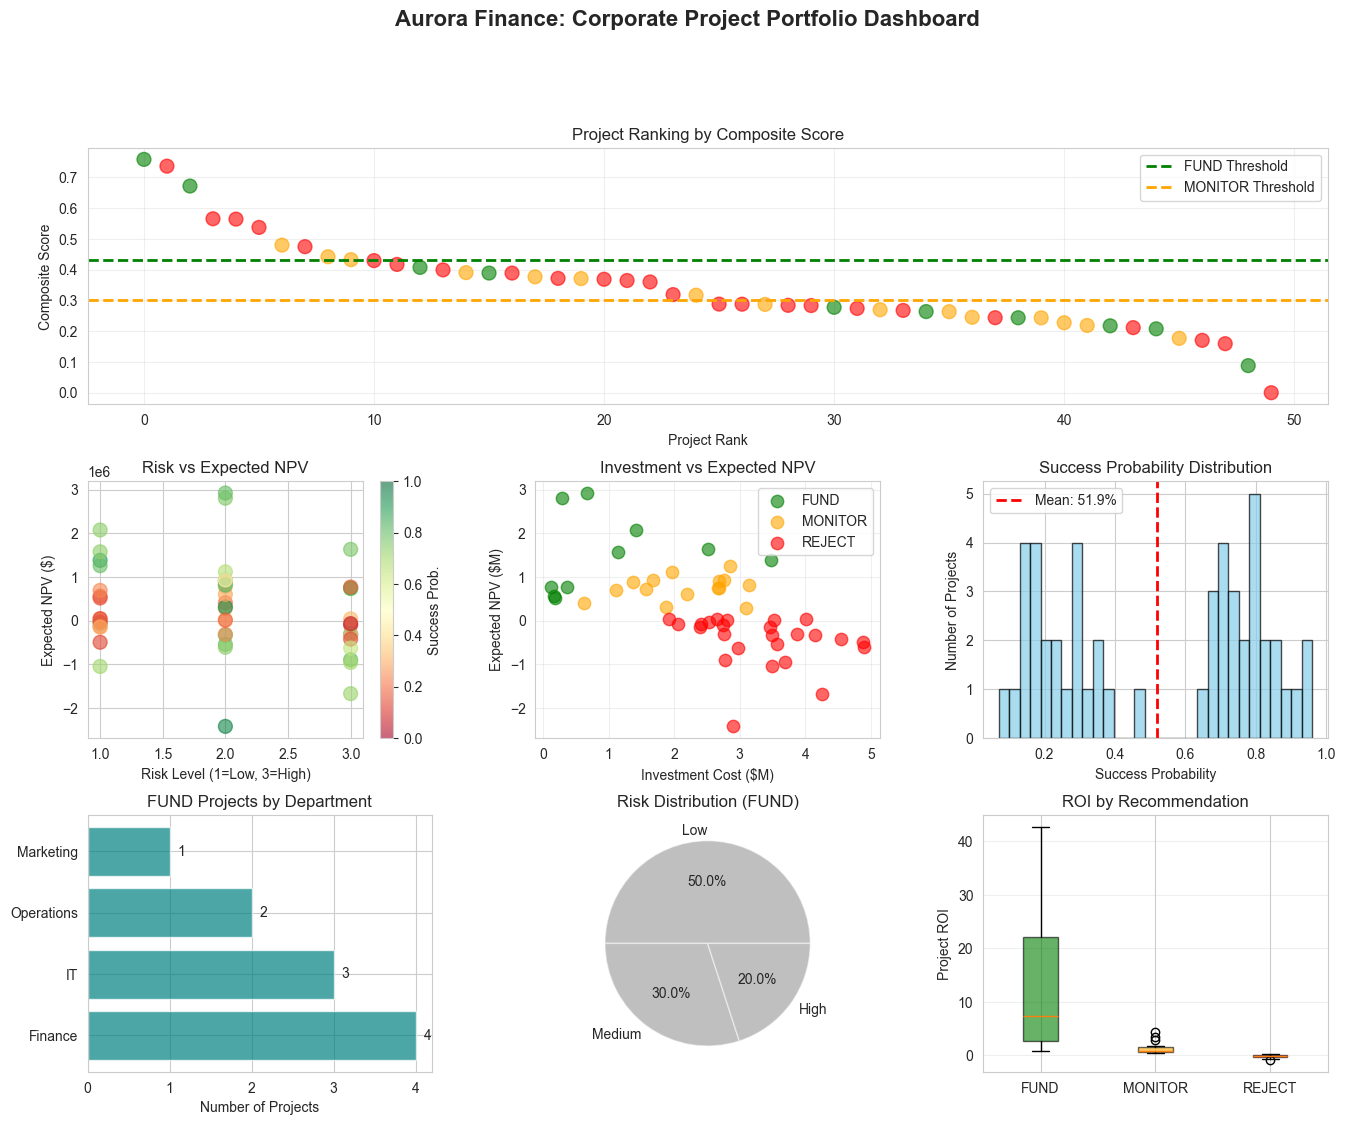

Portfolio Dashboard Generated!


In [22]:
# Create comprehensive portfolio dashboard (simplified)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Create color map for recommendations
rec_colors = {'FUND': 'green', 'MONITOR': 'orange', 'REJECT': 'red'}
ranking_df['color'] = ranking_df['Recommendation'].map(rec_colors)

# 1. Composite Score Distribution with Recommendation Zones
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(range(len(ranking_df)), ranking_df['Composite_Score'], c=ranking_df['color'], alpha=0.6, s=100)
ax1.axhline(ranking_df['Composite_Score'].quantile(0.80), color='green', linestyle='--', linewidth=2, label='FUND Threshold')
ax1.axhline(ranking_df['Composite_Score'].quantile(0.50), color='orange', linestyle='--', linewidth=2, label='MONITOR Threshold')
ax1.set_xlabel('Project Rank')
ax1.set_ylabel('Composite Score')
ax1.set_title('Project Ranking by Composite Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Expected NPV vs Risk
ax2 = fig.add_subplot(gs[1, 0])
scatter2 = ax2.scatter(df['Risk_Score'], df['Expected_NPV'], c=df['Predicted_Success_Probability'], 
                       cmap='RdYlGn', s=100, alpha=0.6, vmin=0, vmax=1)
ax2.set_xlabel('Risk Level (1=Low, 3=High)')
ax2.set_ylabel('Expected NPV ($)')
ax2.set_title('Risk vs Expected NPV')
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Success Prob.')

# 3. Investment vs Expected Return
ax3 = fig.add_subplot(gs[1, 1])
for rec in ['FUND', 'MONITOR', 'REJECT']:
    mask = df['Recommendation'] == rec
    if mask.sum() > 0:
        ax3.scatter(df[mask]['Investment_Cost']/1e6, df[mask]['Expected_NPV']/1e6, 
                   label=rec, alpha=0.6, s=80, color=rec_colors[rec])
ax3.set_xlabel('Investment Cost ($M)')
ax3.set_ylabel('Expected NPV ($M)')
ax3.set_title('Investment vs Expected NPV')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Success Probability Distribution
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(df['Predicted_Success_Probability'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
mean_prob = df['Predicted_Success_Probability'].mean()
ax4.axvline(mean_prob, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_prob:.1%}')
ax4.set_xlabel('Success Probability')
ax4.set_ylabel('Number of Projects')
ax4.set_title('Success Probability Distribution')
ax4.legend()

# 5. Department Breakdown (FUND projects)
ax5 = fig.add_subplot(gs[2, 0])
dept_fund = df[df['Recommendation'] == 'FUND']['Department'].value_counts()
if len(dept_fund) > 0:
    ax5.barh(dept_fund.index, dept_fund.values, color='teal', alpha=0.7)
    ax5.set_xlabel('Number of Projects')
    ax5.set_title('FUND Projects by Department')
    for i, v in enumerate(dept_fund.values):
        ax5.text(v + 0.1, i, str(v), va='center')
else:
    ax5.text(0.5, 0.5, 'No FUND projects', ha='center', va='center')
    ax5.set_title('FUND Projects by Department')

# 6. Risk Distribution (FUND projects)
ax6 = fig.add_subplot(gs[2, 1])
risk_fund = df[df['Recommendation'] == 'FUND']['Project_Risk'].value_counts()
if len(risk_fund) > 0:
    colors_pie = [rec_colors.get(r, 'gray') for r in risk_fund.index]
    ax6.pie(risk_fund.values, labels=risk_fund.index, autopct='%1.1f%%', colors=colors_pie, wedgeprops={'alpha': 0.5})
    ax6.set_title('Risk Distribution (FUND)')
else:
    ax6.text(0.5, 0.5, 'No FUND projects', ha='center', va='center')

# 7. ROI Comparison
ax7 = fig.add_subplot(gs[2, 2])
roi_data = []
roi_labels = []
for rec in ['FUND', 'MONITOR', 'REJECT']:
    roi_vals = df[df['Recommendation'] == rec]['Project_ROI'].values
    if len(roi_vals) > 0:
        roi_data.append(roi_vals)
        roi_labels.append(rec)

if roi_data:
    bp = ax7.boxplot(roi_data, labels=roi_labels, patch_artist=True)
    for patch, label in zip(bp['boxes'], roi_labels):
        patch.set_facecolor(rec_colors[label])
        patch.set_alpha(0.6)
    ax7.set_ylabel('Project ROI')
    ax7.set_title('ROI by Recommendation')
    ax7.grid(True, alpha=0.3, axis='y')

plt.suptitle('Aurora Finance: Corporate Project Portfolio Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("Portfolio Dashboard Generated!")

## 12. Export Results

In [19]:
# Export comprehensive results
export_df = df[[
    'Project_ID', 'Department', 'Investment_Cost', 'Total_Cashflow', 'NPV',
    'Profitability_Index', 'Expected_NPV', 'Predicted_Success_Probability',
    'Project_Risk', 'Historical_ROI', 'Market_Growth', 'Composite_Score',
    'Recommendation', 'Success'
]].copy()

export_df = export_df.sort_values('Composite_Score', ascending=False)
export_df.to_csv('Part1_Project_Recommendations.csv', index=False)

print("Results exported to 'Part1_Project_Recommendations.csv'")
print(f"\nExport Summary:")
print(f"  Total Rows: {len(export_df)}")
print(f"  Columns: {', '.join(export_df.columns)}")
print(f"\nFirst 5 rows:")
print(export_df.head(5))

Results exported to 'Part1_Project_Recommendations.csv'

Export Summary:
  Total Rows: 50
  Columns: Project_ID, Department, Investment_Cost, Total_Cashflow, NPV, Profitability_Index, Expected_NPV, Predicted_Success_Probability, Project_Risk, Historical_ROI, Market_Growth, Composite_Score, Recommendation, Success

First 5 rows:
    Project_ID  Department  Investment_Cost  Total_Cashflow           NPV  \
48          49          IT           123247         5390300  4.281887e+06   
34          35          IT           296769         4710947  3.690876e+06   
42          43          IT           664685         5317073  3.653868e+06   
0            1  Operations           184654         4821128  3.706072e+06   
15          16     Finance           168148         4296748  3.290090e+06   

    Profitability_Index  Expected_NPV  Predicted_Success_Probability  \
48            35.742320  7.707396e+05                           0.18   
34            13.436865  2.805066e+06                          

In [20]:
# Model Summary Report
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
print(f"\n1️⃣  REGRESSION MODEL (Total Cashflow Prediction):")
print(f"   • Model: Random Forest Regressor (100 trees, max_depth=10)")
print(f"   • Train R²: {train_r2:.4f}")
print(f"   • Test R²: {test_r2:.4f}")
print(f"   • Test RMSE: ${test_rmse:,.0f}")
print(f"   • Top Feature: {feature_imp_reg.iloc[0]['Feature']} ({feature_imp_reg.iloc[0]['Importance']:.2%})")

print(f"\n2️⃣  CLASSIFICATION MODEL (Success Prediction):")
print(f"   • Model: Random Forest Classifier (100 trees, max_depth=10)")
print(f"   • Train Accuracy: {train_acc:.4f}")
print(f"   • Test Accuracy: {test_acc:.4f}")
print(f"   • Test AUC-ROC: {test_auc:.4f}")
print(f"   • Top Feature: {feature_imp_clf.iloc[0]['Feature']} ({feature_imp_clf.iloc[0]['Importance']:.2%})")

print(f"\n3️⃣  VALUATION METRICS:")
print(f"   • Average Discount Rate: 10%")
print(f"   • Portfolio NPV (all projects): ${df['NPV'].sum():,.0f}")
print(f"   • Portfolio Expected NPV (risk-adjusted): ${df['Expected_NPV'].sum():,.0f}")
print(f"   • Portfolio Profitability Index: {df['Profitability_Index'].mean():.3f}")

print("\n" + "="*80)


MODEL PERFORMANCE SUMMARY

1️⃣  REGRESSION MODEL (Total Cashflow Prediction):
   • Model: Random Forest Regressor (100 trees, max_depth=10)
   • Train R²: 0.8255
   • Test R²: 0.0573
   • Test RMSE: $1,544,547
   • Top Feature: Investment_Cost (41.86%)

2️⃣  CLASSIFICATION MODEL (Success Prediction):
   • Model: Random Forest Classifier (100 trees, max_depth=10)
   • Train Accuracy: 1.0000
   • Test Accuracy: 0.4000
   • Test AUC-ROC: 0.4400
   • Top Feature: Investment_Cost (34.23%)

3️⃣  VALUATION METRICS:
   • Average Discount Rate: 10%
   • Portfolio NPV (all projects): $29,267,361
   • Portfolio Expected NPV (risk-adjusted): $15,037,501
   • Portfolio Profitability Index: 3.229

